# GridLock Demand Forecasting Solution

This notebook develops a demand forecasting pipeline for traffic locations using spatial, temporal, weather, and road infrastructure features. The approach combines advanced feature engineering, geospatial intelligence, clustering techniques, and an ensemble of CatBoost models to achieve robust predictive performance.

# Exploratory Data Analysis (EDA)

The objective of this section is to understand the distribution of demand, identify temporal patterns, analyze feature relationships, and uncover potential correlations between traffic demand and environmental or road-related variables.

In [ ]:
!pip install catboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import time
from catboost import CatBoostRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score
import seaborn as sns

warnings.filterwarnings('ignore')

# 1. LOAD DATA

print("="*60)
print("LOADING DATA")
print("="*60)

train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

print(f"Train Shape : {train.shape}")
print(f"Test Shape  : {test.shape}")

# 2. BASIC DATA CHECK

print("\nMissing Values")
print(train.isnull().sum())

print("\nDemand Summary")
print(train['demand'].describe())

print("\nDay Distribution")
print(train['day'].value_counts())

print("\nRoad Type Breakdown")
print(
    train.groupby('RoadType')['demand']
         .agg(['mean','median','std','count'])
         .sort_values('mean', ascending=False)
)

print("\nWeather Breakdown")
print(
    train.groupby('Weather')['demand']
         .agg(['mean','median','std','count'])
         .sort_values('mean', ascending=False)
)

print("\nLanes Breakdown")
print(
    train.groupby('NumberofLanes')['demand']
         .agg(['mean','median','std','count'])
         .sort_values('mean', ascending=False)
)

LOADING DATA
Train Shape : (77299, 11)
Test Shape  : (41778, 10)

Missing Values
Index               0
geohash             0
day                 0
timestamp           0
demand              0
RoadType          600
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      2495
Weather           797
dtype: int64

Demand Summary
count    7.729900e+04
mean     9.394238e-02
std      1.421905e-01
min      6.245650e-07
25%      1.822723e-02
50%      4.775994e-02
75%      1.085951e-01
max      1.000000e+00
Name: demand, dtype: float64

Day Distribution
day
48    69427
49     7872
Name: count, dtype: int64

Road Type Breakdown
                 mean    median       std  count
RoadType                                        
Highway      0.610756  0.526432  0.229419   3560
Street       0.273164  0.268124  0.036693   3909
Residential  0.057209  0.040517  0.052057  69230

Weather Breakdown
             mean    median       std  count
Weather                                  

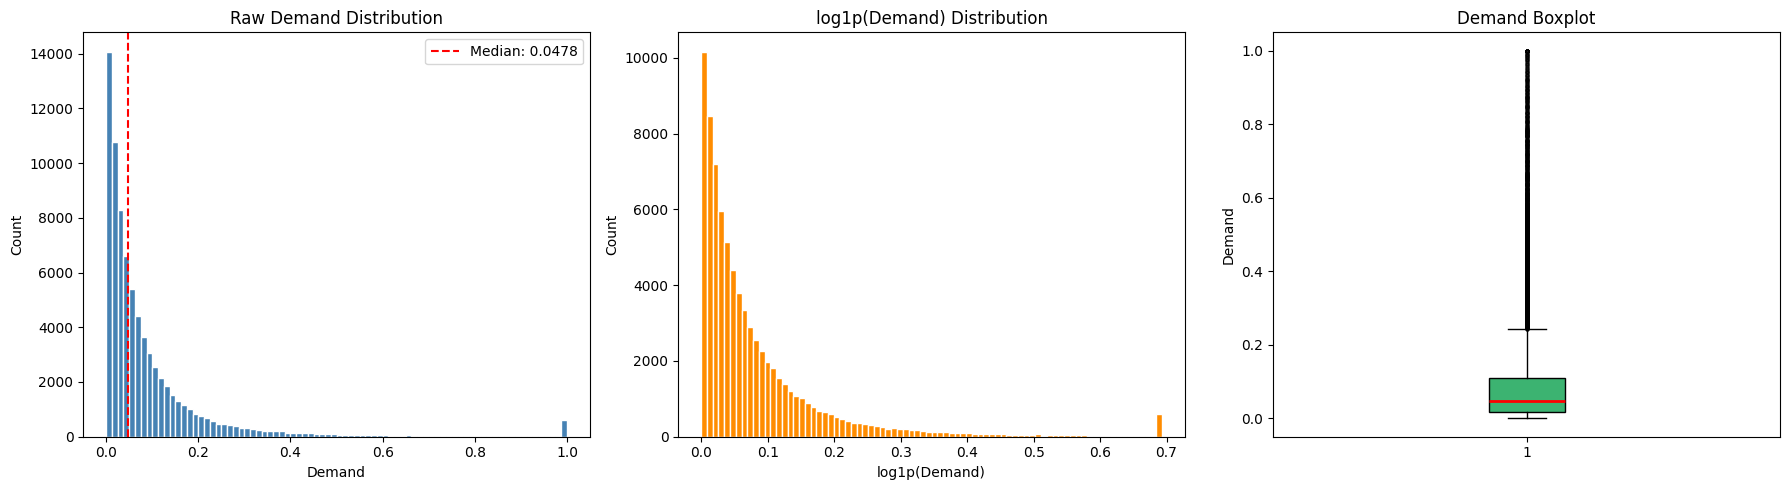

In [ ]:
# 3. EDA PLOTS

# Parse time for EDA
tsplit = train['timestamp'].astype(str).str.split(':')
train['hour']   = tsplit.str[0].astype(int)
train['minute'] = tsplit.str[1].astype(int)

# Demand Distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(train['demand'], bins=80, color='steelblue', edgecolor='white')
axes[0].axvline(train['demand'].median(), color='red', linestyle='--',
                label=f'Median: {train["demand"].median():.4f}')
axes[0].set_title('Raw Demand Distribution')
axes[0].set_xlabel('Demand')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(np.log1p(train['demand']), bins=80, color='darkorange', edgecolor='white')
axes[1].set_title('log1p(Demand) Distribution')
axes[1].set_xlabel('log1p(Demand)')
axes[1].set_ylabel('Count')

axes[2].boxplot(train['demand'], patch_artist=True,
                boxprops=dict(facecolor='mediumseagreen'),
                medianprops=dict(color='red', linewidth=2),
                flierprops=dict(markersize=2, alpha=0.3))
axes[2].set_title('Demand Boxplot')
axes[2].set_ylabel('Demand')

plt.tight_layout()
plt.show()

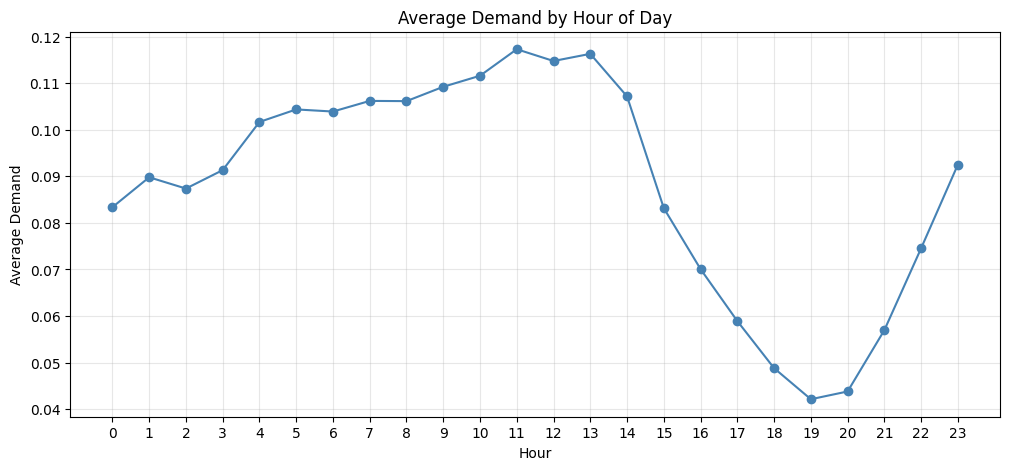

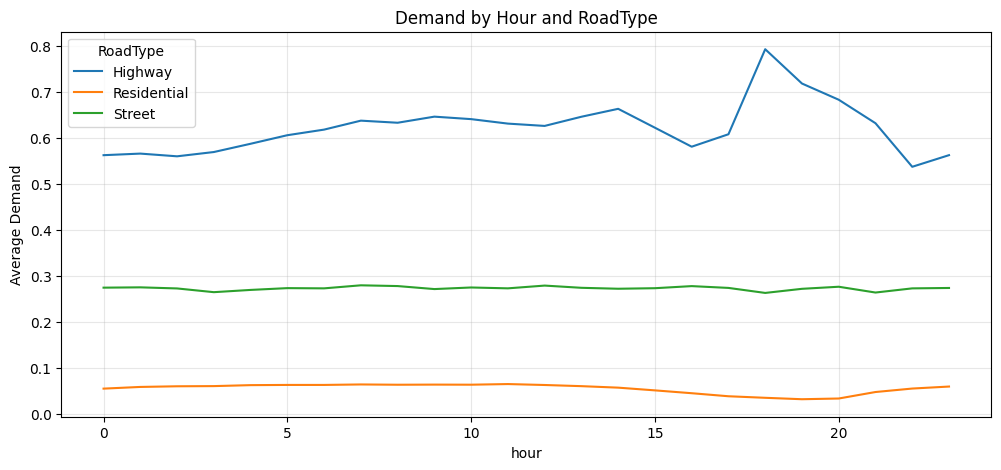

In [ ]:
# Hourly demand pattern
hourly = train.groupby('hour')['demand'].mean()

plt.figure(figsize=(12, 5))
plt.plot(hourly.index, hourly.values, marker='o', color='steelblue')
plt.xlabel('Hour')
plt.ylabel('Average Demand')
plt.title('Average Demand by Hour of Day')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.show()

# Demand by Hour and RoadType
hour_road = (
    train.groupby(['hour', 'RoadType'])['demand']
         .mean()
         .unstack()
)

hour_road.plot(figsize=(12, 5))
plt.title('Demand by Hour and RoadType')
plt.ylabel('Average Demand')
plt.grid(True, alpha=0.3)
plt.show()

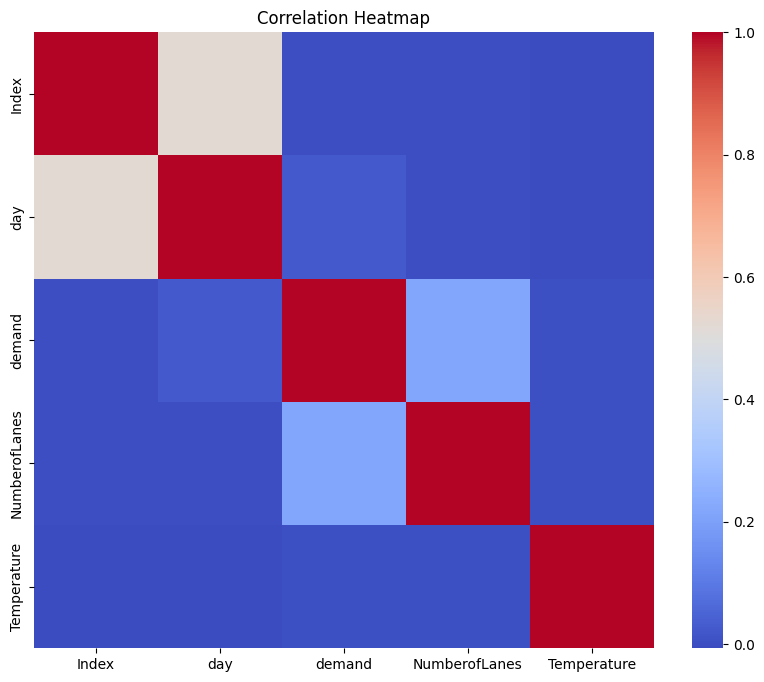

In [ ]:
num_cols = train.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))
sns.heatmap(num_cols.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

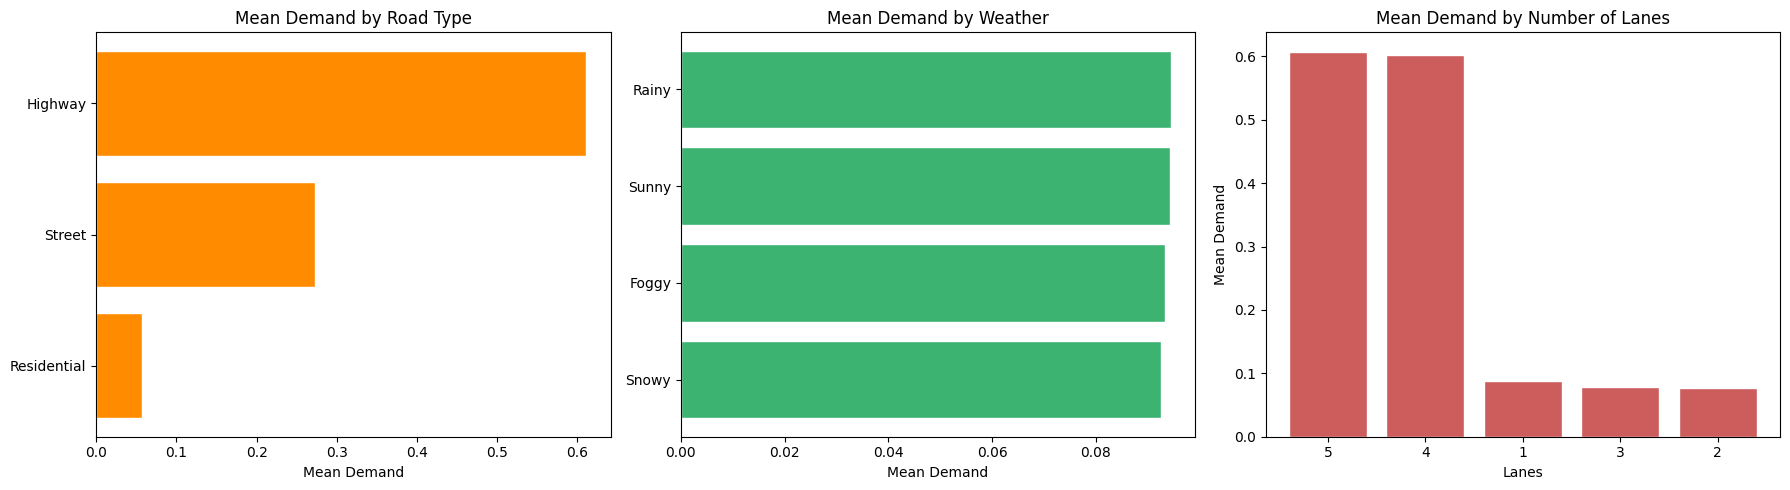

In [ ]:
# Categorical analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

rd = train.groupby('RoadType')['demand'].mean().sort_values(ascending=True)
axes[0].barh(rd.index.astype(str), rd.values, color='darkorange', edgecolor='white')
axes[0].set_title('Mean Demand by Road Type')
axes[0].set_xlabel('Mean Demand')

wt = train.groupby('Weather')['demand'].mean().sort_values(ascending=True)
axes[1].barh(wt.index.astype(str), wt.values, color='mediumseagreen', edgecolor='white')
axes[1].set_title('Mean Demand by Weather')
axes[1].set_xlabel('Mean Demand')

ln = train.groupby('NumberofLanes')['demand'].mean().sort_values(ascending=False)
axes[2].bar(ln.index.astype(str), ln.values, color='indianred', edgecolor='white')
axes[2].set_title('Mean Demand by Number of Lanes')
axes[2].set_xlabel('Lanes')
axes[2].set_ylabel('Mean Demand')

plt.tight_layout()
plt.show()

Geohash Mean Demand Distribution
count    1249.000000
mean        0.064671
std         0.099861
min         0.000495
25%         0.012661
50%         0.030807
75%         0.075227
max         0.960715
Name: mean, dtype: float64

Top 10 Highest Demand Geohashes
             mean       std  count
geohash                           
qp09d9   0.960715  0.090041    105
qp09ft   0.868850  0.209092    105
qp09e5   0.864989  0.239612    105
qp09d8   0.669318  0.234383    105
qp096x   0.665630  0.296666    105
qp09d2   0.664722  0.334164    105
qp09dc   0.661462  0.368198    105
qp096r   0.650468  0.344110    105
qp09d3   0.643498  0.295267    105
qp03xx   0.631194  0.346098    105

Correlation Matrix
               Temperature  NumberofLanes   hour  minute  demand
Temperature          1.000          0.003  0.000  -0.002   0.003
NumberofLanes        0.003          1.000 -0.003   0.000   0.214
hour                 0.000         -0.003  1.000   0.015  -0.038
minute              -0.002          0.0

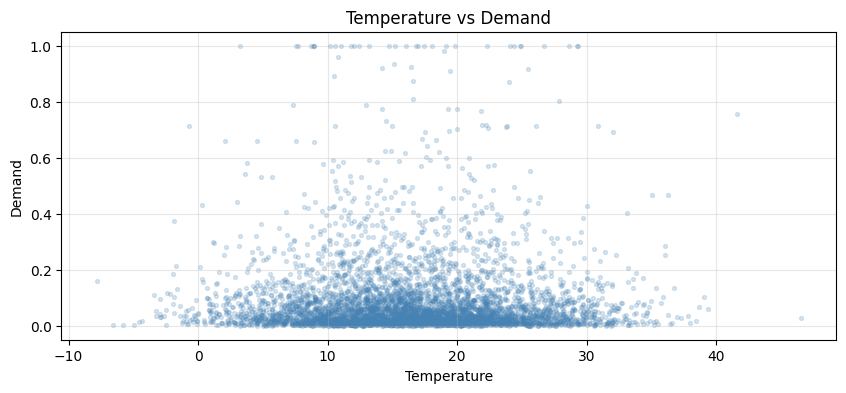

In [ ]:
# Geohash statistics
geo_stats = (
    train.groupby('geohash')['demand']
         .agg(['mean', 'std', 'count'])
)

print("Geohash Mean Demand Distribution")
print(geo_stats['mean'].describe())

print("\nTop 10 Highest Demand Geohashes")
print(geo_stats.sort_values('mean', ascending=False).head(10))

# Correlation of numerical features
num_cols = ['Temperature', 'NumberofLanes', 'hour', 'minute', 'demand']
print("\nCorrelation Matrix")
print(train[num_cols].corr().round(3))

# Temperature vs Demand
sample = train.sample(5000, random_state=42)
plt.figure(figsize=(10, 4))
plt.scatter(sample['Temperature'], sample['demand'], alpha=0.2, s=8, color='steelblue')
plt.title('Temperature vs Demand')
plt.xlabel('Temperature')
plt.ylabel('Demand')
plt.grid(True, alpha=0.3)
plt.show()

# Drop EDA columns before processing
train = train.drop(columns=['hour', 'minute'])

# Geospatial Decoding

The provided geohash locations are decoded into latitude and longitude coordinates. This transformation enables the model to leverage spatial information and derive location-based features for demand prediction.

In [ ]:
# 4. GEOHASH DECODER


def decode_geohash(geohash_str):
    base32 = '0123456789bcdefghjkmnpqrstuvwxyz'
    bits = []
    for char in geohash_str:
        idx = base32.index(char)
        bits.extend([int(b) for b in format(idx, '05b')])
    lat_bits = bits[1::2]
    lon_bits = bits[0::2]
    def bits_to_coord(bit_list, min_val, max_val):
        for bit in bit_list:
            mid = (min_val + max_val) / 2
            if bit: min_val = mid
            else: max_val = mid
        return (min_val + max_val) / 2
    return bits_to_coord(lat_bits, -90, 90), bits_to_coord(lon_bits, -180, 180)

print("Geohash decoder ready")

Geohash decoder ready


# Target Transformation

Demand values often contain extreme outliers and skewed distributions. To stabilize training and improve model learning, the target variable is capped and transformed using logarithmic scaling.

--- TARGET TRANSFORM ---
99.5th percentile cap: 1.00000
Rows affected: 0


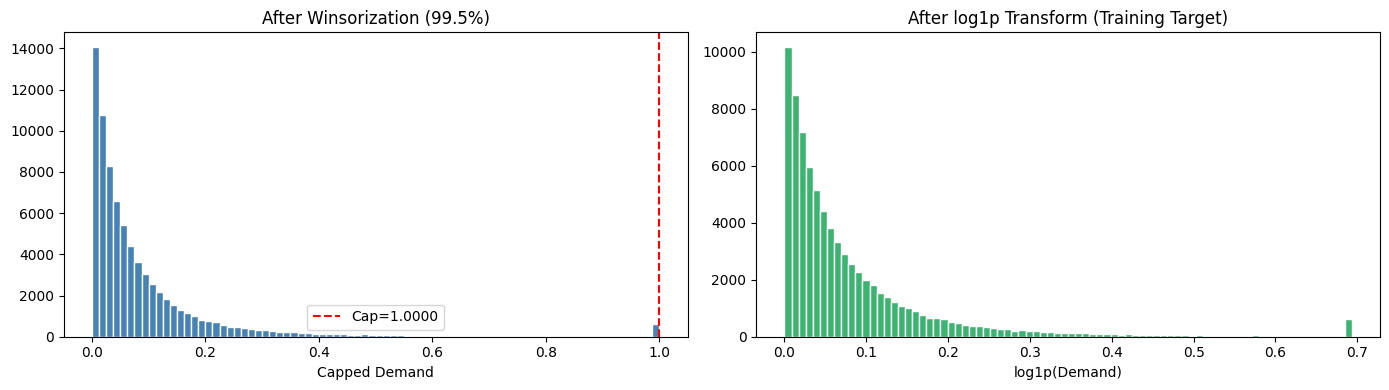

In [ ]:
# 5. TARGET TRANSFORM


print("--- TARGET TRANSFORM ---")

# Winsorize top 0.5% outliers
cap_value = np.percentile(train['demand'], 99.5)
print(f"99.5th percentile cap: {cap_value:.5f}")
print(f"Rows affected: {(train['demand'] > cap_value).sum()}")

train['demand_capped'] = np.clip(train['demand'], 0, cap_value)
train['log_demand']    = np.log1p(train['demand_capped'])

# Visualize transform
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(train['demand_capped'], bins=80, color='steelblue', edgecolor='white')
axes[0].axvline(cap_value, color='red', linestyle='--', label=f'Cap={cap_value:.4f}')
axes[0].set_title('After Winsorization (99.5%)')
axes[0].set_xlabel('Capped Demand')
axes[0].legend()

axes[1].hist(train['log_demand'], bins=80, color='mediumseagreen', edgecolor='white')
axes[1].set_title('After log1p Transform (Training Target)')
axes[1].set_xlabel('log1p(Demand)')

plt.tight_layout()
plt.show()

# Missing Value Handling

Missing categorical and numerical attributes are imputed using domain-aware strategies to preserve information while ensuring consistency across the training and test datasets.

In [ ]:
# 6. MISSING VALUE HANDLING

print("--- MISSING VALUE HANDLING ---")

# Categoricals -> 'Unknown'
cat_cols = ['RoadType', 'Weather', 'LargeVehicles', 'Landmarks']
for col in cat_cols:
    train[col] = train[col].fillna('Unknown').astype(str)
    test[col]  = test[col].fillna('Unknown').astype(str)

# Temperature -> ffill/bfill by geohash, then median
train['Temperature'] = train.groupby('geohash')['Temperature'].ffill().bfill()
train['Temperature'].fillna(train['Temperature'].median(), inplace=True)
test['Temperature']  = test.groupby('geohash')['Temperature'].ffill().bfill()
test['Temperature'].fillna(train['Temperature'].median(), inplace=True)

print(f"Train nulls remaining: {train.isnull().sum().sum()}")
print(f"Test nulls remaining:  {test.isnull().sum().sum()}")

--- MISSING VALUE HANDLING ---
Train nulls remaining: 0
Test nulls remaining:  0


# Advanced Feature Engineering

This section creates informative predictors from temporal, spatial, weather, road infrastructure, and traffic characteristics. The goal is to expose hidden patterns that improve forecasting performance.

In [ ]:
# 7. FEATURE ENGINEERING

print("--- FEATURE ENGINEERING ---")

def engineer_features(df):
    df = df.copy()

    # Time features
    time_split = df['timestamp'].astype(str).str.split(':')
    df['Hour']         = time_split.str[0].astype(int)
    df['Minute']       = time_split.str[1].astype(int)
    df['Quarter_Hour'] = (df['Minute'] // 15).astype(str)

    # Cyclical encoding
    total_minutes  = df['Hour'] * 60 + df['Minute']
    df['Hour_sin'] = np.sin(2 * np.pi * total_minutes / 1440.0)
    df['Hour_cos'] = np.cos(2 * np.pi * total_minutes / 1440.0)

    # Day of week
    df['DayOfWeek'] = df['day'] % 7
    df['IsWeekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

    # Spatial features
    geo_cache = {}
    for gh in df['geohash'].unique():
        if gh not in geo_cache:
            geo_cache[gh] = decode_geohash(gh)
    df['Latitude']  = df['geohash'].map(lambda x: geo_cache[x][0])
    df['Longitude'] = df['geohash'].map(lambda x: geo_cache[x][1])

    # Distance to grid center
    df['Dist_to_Center'] = np.sqrt(
        (df['Latitude'] - 1.29)**2 + (df['Longitude'] - 103.85)**2
    )

    # Ensure categoricals are strings for CatBoost
    for col in ['geohash', 'RoadType', 'LargeVehicles', 'Landmarks', 'Weather', 'Quarter_Hour']:
        df[col] = df[col].astype(str)

    df = df.drop(columns=['timestamp'])
    return df

train = engineer_features(train)
test  = engineer_features(test)

print(f"Train shape after FE: {train.shape}")
print(f"Test shape after FE:  {test.shape}")

--- FEATURE ENGINEERING ---
Train shape after FE: (77299, 22)
Test shape after FE:  (41778, 19)


# Spatial Zone Discovery using K-Means

Locations with similar geographic characteristics are grouped into spatial clusters. These learned zones help the model capture regional demand behavior that may not be directly represented by raw coordinates.

Computing KMeans spatial zones (k=8)...


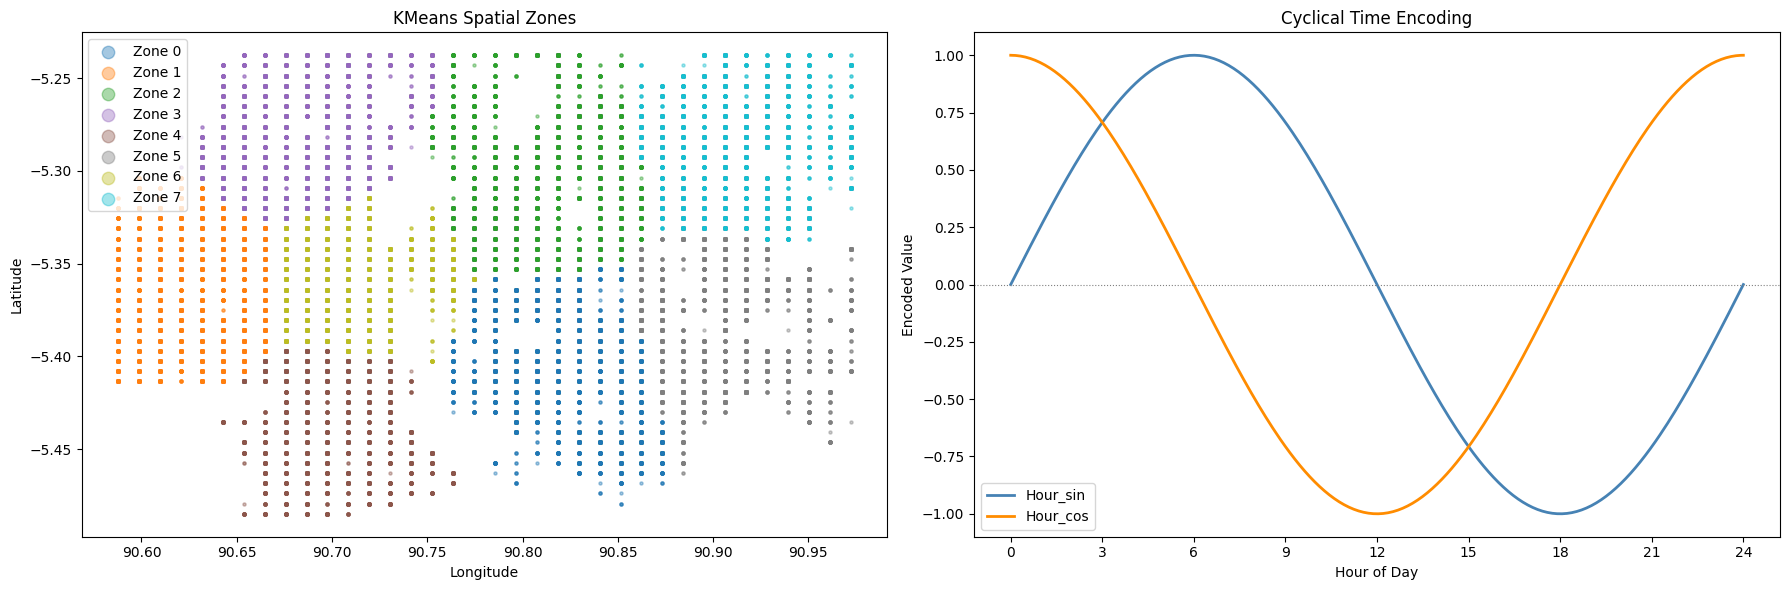


Zone distribution:
Spatial_Zone
0     9538
1    12165
2    11448
3    10817
4     7281
5     7699
6     9502
7     8849
Name: count, dtype: int64


In [ ]:
# 8. KMEANS SPATIAL CLUSTERING

print("Computing KMeans spatial zones (k=8)...")

kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
train['Spatial_Zone'] = kmeans.fit_predict(train[['Latitude', 'Longitude']]).astype(str)
test['Spatial_Zone']  = kmeans.predict(test[['Latitude', 'Longitude']]).astype(str)

# Visualize spatial zones
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

colors = plt.cm.tab10(np.linspace(0, 1, 8))
for zone in range(8):
    mask = train['Spatial_Zone'] == str(zone)
    axes[0].scatter(train.loc[mask, 'Longitude'], train.loc[mask, 'Latitude'],
                    c=[colors[zone]], s=5, alpha=0.4, label=f'Zone {zone}')

axes[0].set_title('KMeans Spatial Zones')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].legend(markerscale=4)

# Cyclical encoding visualization
t = np.linspace(0, 1440, 300)
axes[1].plot(t/60, np.sin(2*np.pi*t/1440), label='Hour_sin', color='steelblue', linewidth=2)
axes[1].plot(t/60, np.cos(2*np.pi*t/1440), label='Hour_cos', color='darkorange', linewidth=2)
axes[1].axhline(0, color='gray', linestyle=':', linewidth=0.8)
axes[1].set_title('Cyclical Time Encoding')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Encoded Value')
axes[1].set_xticks(range(0, 25, 3))
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nZone distribution:")
print(train['Spatial_Zone'].value_counts().sort_index())

# Model Input Preparation

The engineered features are assembled into the final training and testing matrices. Irrelevant identifiers and target-related columns are removed to prevent information leakage.

In [ ]:
# 9. PREPARE FEATURES

drop_cols = ['Index', 'demand', 'demand_capped', 'log_demand', 'day']
features  = [col for col in train.columns if col not in drop_cols]

cat_features = [
    'geohash', 'RoadType', 'LargeVehicles', 'Landmarks',
    'Weather', 'Quarter_Hour', 'Spatial_Zone'
]

print(f"Total features: {len(features)}")
print(f"Categorical:    {len(cat_features)}")
print(f"Numeric:        {len(features) - len(cat_features)}")
print(f"\nFeature list: {features}")

X_full     = train[features]
y_full_log = train['log_demand']
X_test     = test[features]
test_index = test['Index'].astype(int)

print(f"\nX_full: {X_full.shape}")
print(f"X_test: {X_test.shape}")

Total features: 18
Categorical:    7
Numeric:        11

Feature list: ['geohash', 'RoadType', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather', 'Hour', 'Minute', 'Quarter_Hour', 'Hour_sin', 'Hour_cos', 'DayOfWeek', 'IsWeekend', 'Latitude', 'Longitude', 'Dist_to_Center', 'Spatial_Zone']

X_full: (77299, 18)
X_test: (41778, 18)


# Multi-Seed CatBoost Ensemble

Multiple CatBoost models are trained using different random seeds. This ensemble strategy reduces variance, improves generalization, and increases prediction stability across unseen locations.

In [ ]:
# 10. MULTI-SEED CATBOOST TRAINING

print("="*60)
print("TRAINING CATBOOST (5 seeds)")
print("="*60)

t0 = time.time()

SEEDS     = [42, 0, 7, 13, 99]
eps       = 1e-8
all_preds = []

for i, seed in enumerate(SEEDS):
    print(f"\n--- Seed {seed} ({i+1}/{len(SEEDS)}) ---")

    model = CatBoostRegressor(
        iterations    = 2000,
        learning_rate = 0.06,
        depth         = 7,
        eval_metric   = 'RMSE',
        cat_features  = cat_features,
        random_seed   = seed,
        verbose       = 500
    )

    model.fit(X_full, y_full_log)

    # Predict and reverse log1p
    preds_log    = model.predict(X_test)
    preds_actual = np.clip(np.expm1(preds_log), 0, None)
    all_preds.append(preds_actual)

    print(f"  Mean prediction: {preds_actual.mean():.6f}")

print(f"\nAll {len(SEEDS)} models trained in {(time.time()-t0)/60:.1f} min")

TRAINING CATBOOST (5 seeds)

--- Seed 42 (1/5) ---
0:	learn: 0.1040264	total: 156ms	remaining: 5m 11s
500:	learn: 0.0271540	total: 49.5s	remaining: 2m 28s
1000:	learn: 0.0246577	total: 1m 41s	remaining: 1m 41s
1500:	learn: 0.0233982	total: 2m 34s	remaining: 51.2s
1999:	learn: 0.0225371	total: 3m 26s	remaining: 0us
  Mean prediction: 0.127688

--- Seed 0 (2/5) ---
0:	learn: 0.1040557	total: 124ms	remaining: 4m 8s
500:	learn: 0.0269182	total: 48s	remaining: 2m 23s
1000:	learn: 0.0246920	total: 1m 38s	remaining: 1m 38s
1500:	learn: 0.0234485	total: 2m 31s	remaining: 50.3s
1999:	learn: 0.0225417	total: 3m 23s	remaining: 0us
  Mean prediction: 0.127955

--- Seed 7 (3/5) ---
0:	learn: 0.1040508	total: 113ms	remaining: 3m 46s
500:	learn: 0.0270213	total: 52.4s	remaining: 2m 36s
1000:	learn: 0.0245744	total: 1m 44s	remaining: 1m 44s
1500:	learn: 0.0233910	total: 2m 36s	remaining: 52.1s
1999:	learn: 0.0225620	total: 3m 30s	remaining: 0us
  Mean prediction: 0.128560

--- Seed 13 (4/5) ---
0:	lea

# Feature Importance Analysis

Feature importance scores are examined to understand which variables contribute most strongly to demand prediction and to validate the effectiveness of the engineered features.

FEATURE IMPORTANCE

RoadType                  48.0663
geohash                   16.3086
LargeVehicles             10.8906
Hour_sin                  4.4161
Hour_cos                  3.8825
NumberofLanes             3.3307
Hour                      3.1627
Dist_to_Center            2.7337
Latitude                  2.2142
Longitude                 1.7906
Spatial_Zone              1.4827
DayOfWeek                 0.5635
IsWeekend                 0.4910
Weather                   0.2015
Temperature               0.1863
Quarter_Hour              0.1559
Landmarks                 0.0695
Minute                    0.0537


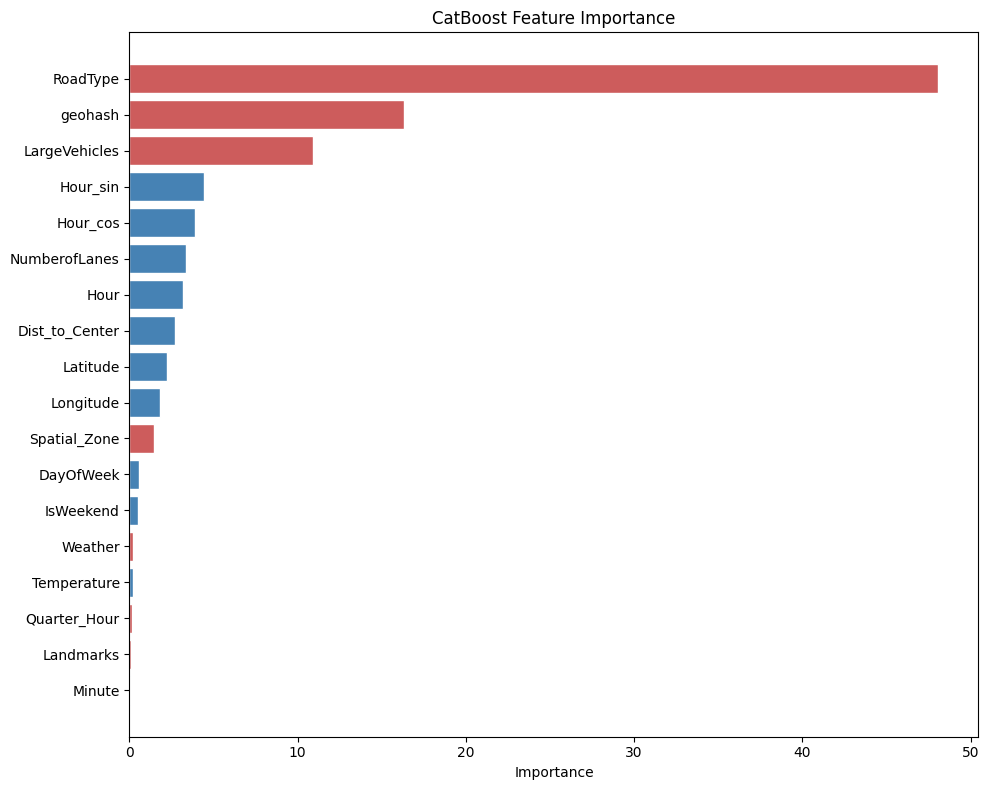

In [ ]:
# 11. FEATURE IMPORTANCE

importance = model.get_feature_importance()
feat_imp = sorted(zip(features, importance), key=lambda x: x[1], reverse=True)

print("FEATURE IMPORTANCE\n")
for feat, imp in feat_imp:
    print(f"{feat:<25} {imp:.4f}")

# Plot
fn, fv = zip(*feat_imp)
c = ['indianred' if f in cat_features else 'steelblue' for f in fn]

plt.figure(figsize=(10, 8))
plt.barh(list(fn)[::-1], list(fv)[::-1], color=c[::-1], edgecolor='white')
plt.title('CatBoost Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# Geometric Mean Ensembling

Predictions from all trained models are combined using geometric averaging. This technique provides a more stable and robust final estimate than relying on a single model.

Building geometric mean ensemble...


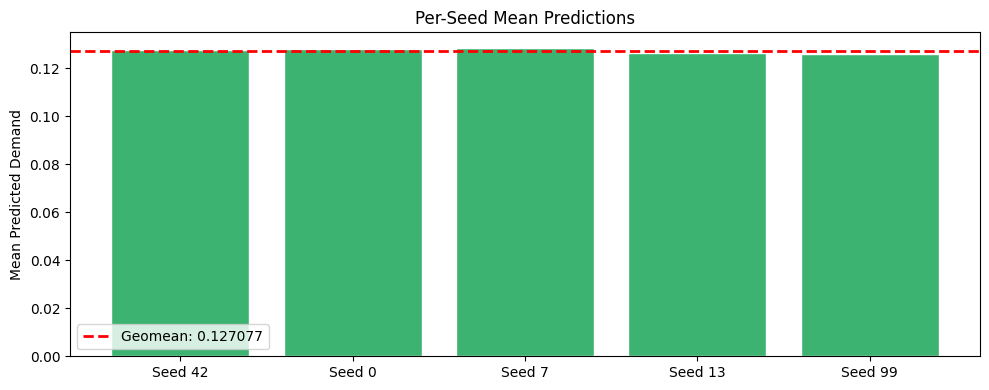


Final prediction range: [0.000000, 1.000000]
Final prediction mean:  0.127077


In [ ]:
# 12. GEOMETRIC MEAN ENSEMBLE

print("Building geometric mean ensemble...")

# Geometric mean: (p1 * p2 * ... * p5) ^ (1/5)
product = np.ones(len(X_test))
for p in all_preds:
    product *= np.maximum(p, eps)
final_pred = np.power(product, 1.0 / len(SEEDS))
final_pred = np.clip(final_pred, 0, 1)

# Compare seeds
plt.figure(figsize=(10, 4))
seed_means = [p.mean() for p in all_preds]
bars = plt.bar([f'Seed {s}' for s in SEEDS], seed_means, color='mediumseagreen', edgecolor='white')
plt.axhline(final_pred.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Geomean: {final_pred.mean():.6f}')
plt.title('Per-Seed Mean Predictions')
plt.ylabel('Mean Predicted Demand')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nFinal prediction range: [{final_pred.min():.6f}, {final_pred.max():.6f}]")
print(f"Final prediction mean:  {final_pred.mean():.6f}")

# Submission File Generation

Final demand predictions are converted back to the original scale and formatted according to the competition requirements for submission.

In [ ]:
# 13. SAVE SUBMISSION

submission = pd.DataFrame({
    'Index': test_index,
    'demand': final_pred
})

submission.to_csv('submission.csv', index=False)

# Verify
assert submission.shape == (41778, 2)
assert list(submission.columns) == ['Index', 'demand']
assert final_pred.min() >= 0 and final_pred.max() <= 1

print("="*60)
print("SUBMISSION SAVED")
print("="*60)
print(f"\nFile:   submission.csv")
print(f"Shape:  {submission.shape}")
print(f"Range:  [{final_pred.min():.6f}, {final_pred.max():.6f}]")
print(f"Mean:   {final_pred.mean():.6f}")

print(submission.head(10))

SUBMISSION SAVED

File:   submission.csv
Shape:  (41778, 2)
Range:  [0.000000, 1.000000]
Mean:   0.127077
   Index    demand
0      0  0.052152
1      1  0.032415
2      2  0.018156
3      3  0.034622
4      4  0.065989
5      5  0.021607
6      6  0.034999
7      7  0.082890
8      8  0.039196
9      9  0.056098
